In [1]:
import json
import os

import ipywidgets as widgets
import numpy as np
import scipy
import simpeg
import simpeg.electromagnetics.time_domain as tdem
from discretize import SimplexMesh
from IPython.display import display
from matplotlib import pyplot as plt
from pymatsolver import Solver
from rich import print
from simpeg import maps
from simpeg.electromagnetics.utils.em1d_utils import (
    get_vertical_discretization,
    set_mesh_1d,
)
from simpeg.regularization.laterally_constrained import LaterallyConstrained
from simpeg.utils import plot_1d_layer_model as plot_1d


In [2]:
if os.getcwd().endswith("notebooks"):
    os.chdir("../")
print(f"Current working directory: {os.getcwd()}")

with open("data/atem.json", "r") as f:
    tmp = json.load(f)
f.close()
channels = np.asarray(tmp["channels"])[3:25] * 1e-6

Current working directory: /Volumes/X31/01.Projects/atem

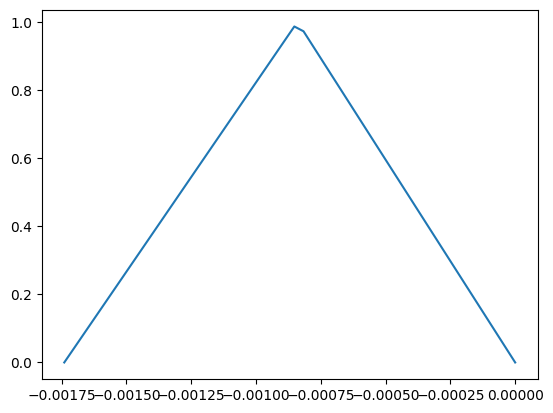

In [3]:
# Waveform
start_time = -1.74e-3
peak_time = -0.84e-3
off_time = 0.0
waveform = tdem.sources.TriangularWaveform(start_time, off_time, peak_time)
current_times = np.linspace(start_time, off_time)
currents = [waveform.eval(t) for t in current_times]
plt.plot(current_times, currents)

In [4]:
# L10051, 224 th sounding
m = [ 43.81728817, 42.57194312, 40.37695455, 37.44482777, 33.86254969, 29.69366515, 25.05296053, 20.18562244, 15.57123765, 11.88377367, 9.6453006, 9.03170756, 10.09772589, 12.90617897, 16.77522594, 19.92504766, 20.74293808, 19.33928613, 17.17501988, 15.55024086, 14.85148158, 14.75013369 ]
d = np.array( [ -1.37475334e-09, -1.10279498e-09, -8.66564125e-10, -7.06151787e-10, -5.83222002e-10, -4.91750993e-10, -4.24256785e-10, -3.65942865e-10, -3.17365283e-10, -2.65697993e-10, -2.20983819e-10, -1.83810101e-10, -1.56528481e-10, -1.32076407e-10, -1.08883441e-10, -8.88984423e-11, -7.33777511e-11, -5.82770091e-11, -4.64261339e-11, -3.61468798e-11, -2.88768335e-11, -1.85408003e-11, ])
# T19110 972 th sounding
m1 = [ 9.63148818, 10.17107292, 11.25610918, 12.79577163, 14.72469571, 16.97856423, 19.4875978, 22.19062404, 25.02924308, 27.9363652, 30.8608197, 33.73006727, 36.42154367, 38.76070617, 40.456483, 41.16868033, 40.66133887, 38.97401131, 36.54420735, 34.00380332, 31.93330634, 30.63045525 ]
d1 = np.array( [ -1.69663323e-09, -1.24710029e-09, -8.73494198e-10, -6.49202490e-10, -4.99531363e-10, -3.90600302e-10, -3.14503773e-10, -2.56667979e-10, -2.13902300e-10, -1.74148605e-10, -1.35714572e-10, -1.07670798e-10, -8.78254569e-11, -7.00912070e-11, -5.42463666e-11, -4.55915903e-11, -3.59651980e-11, -2.91734003e-11, -2.26381588e-11, -1.43485912e-11, -9.34586868e-12, -8.55815929e-12, ])
# T19110 2072 th sounding
m2 = [ 43.60847219, 42.65065163, 40.85641459, 38.4604121, 35.65712399, 32.57809339, 29.34689838, 26.07741926, 22.86394495, 19.79965353, 16.99369191, 14.58913004, 12.7837791, 11.79191843, 11.79772506, 12.66040673, 13.83366095, 14.57929606, 14.59978979, 14.25485958, 14.0049699, 13.95772044 ]
d2 = np.array( [ -1.11803508e-09, -8.44418709e-10, -6.20985908e-10, -4.88576809e-10, -3.99988978e-10, -3.36059151e-10, -2.88986302e-10, -2.50609302e-10, -2.19221546e-10, -1.87375835e-10, -1.56265261e-10, -1.28995036e-10, -1.08350882e-10, -9.10631164e-11, -7.71108536e-11, -6.59532051e-11, -5.37463413e-11, -4.32486238e-11, -3.58261900e-11, -2.81850505e-11, -2.27254885e-11, -1.69651609e-11, ])

# m = [50] *  10 + [10] * 5 + [20] * 7

In [5]:
receiver_orientation = "z"
source_orientation = "z"

tx_rx_x = [-300 + 50 * i for i in range(13)]
tx_rx_y = [-1_400 + 700 * i for i in range(5)]
tx_rx_z = [30.0]

print(
    f"Number of transmitter-receiver locations: {len(tx_rx_x) * len(tx_rx_y) * len(tx_rx_z)}"
)
source_locations = np.c_[
    np.array(tx_rx_x * len(tx_rx_y)),
    np.repeat(np.array(tx_rx_y).reshape(-1, 1), len(tx_rx_x), axis=1).flatten(),
    np.array(tx_rx_z * len(tx_rx_x) * len(tx_rx_y)),
]

receiver_locations = source_locations.copy()

n_soundings = source_locations.shape[0]

Number of transmitter-receiver locations: 65

In [6]:
thickness = get_vertical_discretization(21, 2, 1.17)
hz = np.r_[thickness, thickness[-1]]
nlayer = len(hz)
nP = n_soundings * nlayer
sigma_map = maps.ExpMap(nP=nP)

topo = receiver_locations.copy()
topo[:, 2] = topo[:, 2] - tx_rx_z[0]

>> Depth from the surface to the base of the bottom layer is 306.3m


In [7]:
receiver_list = []
source_list = []
radius: float = 5.0

for i_sounding in range(n_soundings):
    source_location = source_locations[i_sounding, :]
    receiver_location = receiver_locations[i_sounding, :]

    dbzdt_receiver = tdem.receivers.PointMagneticFluxTimeDerivative(
        receiver_location,
        channels,
        receiver_orientation,
    )

    source_list.append(
        tdem.sources.CircularLoop(
            [dbzdt_receiver],
            location=source_location,
            waveform=waveform,
            radius=radius,
            i_sounding=i_sounding,
            orientation=source_orientation,
        )
    )

survey = tdem.Survey(source_list)

In [8]:
simulation = tdem.Simulation1DLayeredStitched(
    survey=survey,
    thicknesses=thickness,
    sigmaMap=sigma_map,
    topo=topo,
    parallel=True,
    n_cpu=8,
    verbose=False,
    solver=Solver,
)

In [9]:
obs = simulation.dpred(np.log(1 / np.array(m * n_soundings)))
obs = obs.reshape(n_soundings, -1)

In [13]:
obs1 = simulation.dpred(np.log(1 / np.array(m1 * n_soundings))).reshape(n_soundings, -1)
obs2 = simulation.dpred(np.log(1 / np.array(m2 * n_soundings))).reshape(n_soundings, -1)

In [14]:
def positive_r(x):
    return x[x>0]

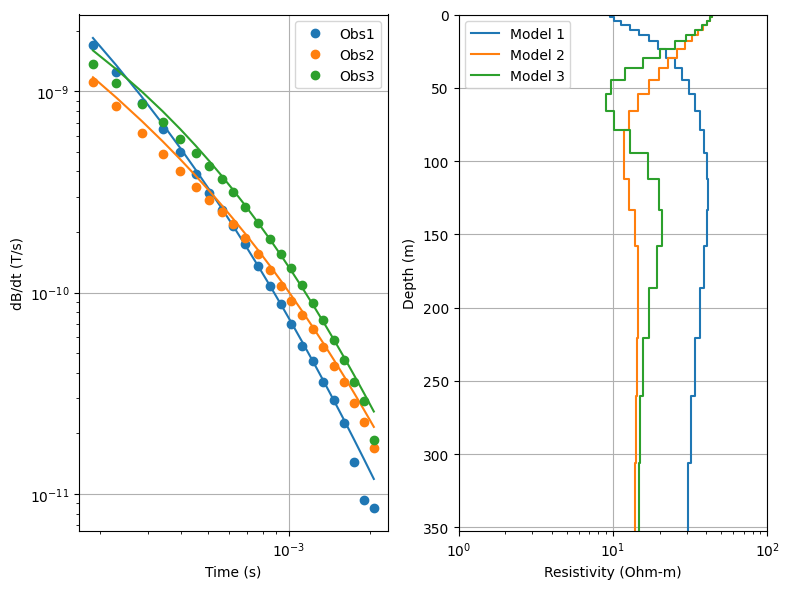

In [15]:
plt.figure(figsize=(8, 6))
plt.subplot(121)
plt.loglog(channels, positive_r(-obs1[0,:]), c="C0")
plt.loglog(channels, positive_r(-d1), "o", c="C0", label="Obs1")
plt.loglog(channels, positive_r(-obs2[0,:]), c="C1")
plt.loglog(channels, positive_r(-d2), "o", c="C1", label="Obs2")
plt.loglog(channels, positive_r(-obs[0,:]), c="C2")
plt.loglog(channels, positive_r(-d), "o", c="C2", label="Obs3")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("dB/dt (T/s)")
plt.grid()
plt.subplot(122)
plot_1d(
    thicknesses=thickness,
    values=m1,
    ax=plt.gca(),
    scale="log",
    plot_elevation=False,
    label="Model 1",
)
plot_1d(
    thicknesses=thickness,
    values=m2,
    ax=plt.gca(),
    scale="log",
    plot_elevation=False,
    label="Model 2",
)
plot_1d(
    thicknesses=thickness,
    values=m,
    ax=plt.gca(),
    scale="log",
    plot_elevation=False,
    label="Model 3",
)
plt.xlabel("Resistivity (Ohm-m)")
plt.legend()
plt.xlim(1, 100)
plt.grid()
plt.tight_layout()
plt.show()

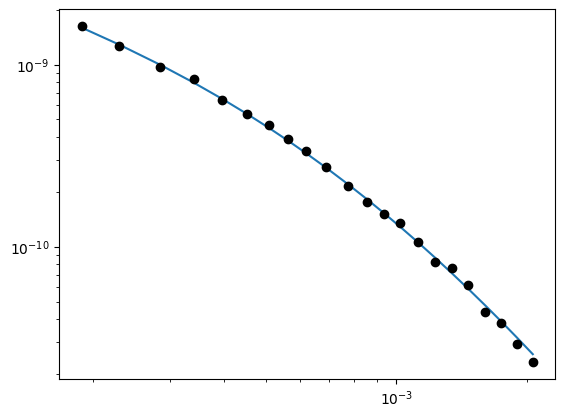

In [ ]:
# Add noise to the data.
np.random.seed(23)

late_criteria = 1e-3 # Late time channels are more sensitive to noise.
late_time_noise = np.zeros(obs.shape)
late_time_noise[:, channels > late_criteria] = np.random.normal(
    0, 0.07, obs[:, channels > late_criteria].shape
)
base_noise = np.zeros(obs.shape)
base_noise[:, channels <= late_criteria] = np.random.normal(
    0, 0.05, obs[:, channels <= late_criteria].shape
)

obs_w_noise = obs * (1 + base_noise + late_time_noise)

plt.loglog(channels, np.abs(obs[0, :]))
plt.loglog(
    channels,
    np.abs(
        obs_w_noise[0,:]
    ),
    "o",
    color = "k"
)

In [ ]:
def get_active_edge_indices_with_distance(
    mesh_radial, mesh_vertical, maximum_distance=1000
):
    nz = mesh_vertical.n_cells
    edge_lengths = mesh_radial.edge_lengths
    inds = edge_lengths < maximum_distance
    indActiveEdges = np.tile(inds.reshape([-1, 1]), nz).flatten()
    return inds, indActiveEdges

In [ ]:
tri = scipy.spatial.Delaunay(source_locations[:, :2])
mesh_radial = SimplexMesh(tri.points, tri.simplices)
mesh_vertical = set_mesh_1d(hz)
mesh_reg = [mesh_radial, mesh_vertical]

# INFO: `indActiveEdges` decides the maximum distance to appl
inds, indActiveEdges = get_active_edge_indices_with_distance(
    mesh_radial, mesh_vertical, maximum_distance=1500.0
)  # TODO: Try to adjust maximum_distance.

In [ ]:
def run_smooth_inversion(uncertainty = 0.05, chifact_target = 1.0):
    floor = 1e-11
    data = simpeg.data.Data(
        survey = survey,
        dobs = obs_w_noise.flatten(),
        standard_deviation = uncertainty * np.abs(obs_w_noise.flatten()) + floor,
    )
    dmis = simpeg.data_misfit.L2DataMisfit(simulation=simulation, data=data)
    opt = simpeg.optimization.ProjectedGNCG(
        maxIter=30, maxIterCG=50
    )
    reg = LaterallyConstrained(
        mesh_reg,
        mapping = simpeg.maps.IdentityMap(nP = nP),
        alpha_s = 0.0,
        alpha_r = 1.0,
        alpha_z = 0.5,
        active_edges = indActiveEdges,
    )
    reg.gradient_type = "total"
    invProb = simpeg.inverse_problem.BaseInvProblem(dmis, reg, opt)

    beta = simpeg.directives.BetaSchedule(
        coolingFactor=2, coolingRate=1
    )  # TODO: Adjust cooling rate
    target = simpeg.directives.TargetMisfit(chifact=chifact_target)
    betaest = simpeg.directives.BetaEstimate_ByEig(beta0_ratio=1.0)
    precond = simpeg.directives.UpdatePreconditioner()
    save_model_dict = simpeg.directives.SaveOutputDictEveryIteration()
    save_model_dict.outDict = {}


    inv = simpeg.inversion.BaseInversion(
        invProb,
        directiveList = [
            beta,
            betaest,
            target,
            precond,
            save_model_dict
        ]
    )
    invProb.counter = opt.counter = simpeg.utils.Counter()
    opt.LSshorten = 0.5
    opt.remember('xc')
    res0 = 10.0
    m0 = np.ones(nP) * np.log(1.0/res0)

    inv.run(m0)

    return save_model_dict.outDict, invProb.dmisfit.nP

In [ ]:
def run_inversion(uncertainty = 0.05, chifact_start = 1.2, chifact_target = 1.0, f_min_change = 1e-5):
    floor = 1e-11
    data = simpeg.data.Data(
        survey = survey,
        dobs = obs_w_noise.flatten(),
        standard_deviation = uncertainty * np.abs(obs_w_noise.flatten()) + floor,
    )
    dmis = simpeg.data_misfit.L2DataMisfit(simulation=simulation, data=data)
    opt = simpeg.optimization.ProjectedGNCG(
        maxIter=30, maxIterCG=50
    )
    reg = LaterallyConstrained(
        mesh_reg,
        mapping = simpeg.maps.IdentityMap(nP = nP),
        alpha_s = 0.0,
        alpha_r = 1.0,
        alpha_z = 0.5,
        active_edges = indActiveEdges,
        norms = np.array([2.0, 0.0, 0.0])
    )
    reg.gradient_type = "total"
    invProb = simpeg.inverse_problem.BaseInvProblem(dmis, reg, opt)

    betaest = simpeg.directives.BetaEstimate_ByEig(beta0_ratio=1.0)
    precond = simpeg.directives.UpdatePreconditioner()
    save_model_dict = simpeg.directives.SaveOutputDictEveryIteration()
    save_model_dict.outDict = {}

    update_irls = simpeg.directives.Update_IRLS(
        coolingFactor = 2.0,
        coolingRate = 1.0,
        f_min_change = f_min_change,
        max_irls_iterations = 40,
        chifact_start = chifact_start,
        chifact_target = chifact_target
    )
    update_irls.coolEpsFact = 2.0

    inv = simpeg.inversion.BaseInversion(
        invProb,
        directiveList = [
            update_irls,
            betaest,
            precond,
            save_model_dict
        ]
    )
    invProb.counter = opt.counter = simpeg.utils.Counter()
    opt.LSshorten = 0.5
    opt.remember('xc')
    res0 = 10.0
    m0 = np.ones(nP) * np.log(1.0/res0)

    inv.run(m0)

    for attr in ["target", "chifact_start", "chifact_target", "f_min_change"]:
        print(f"{attr}:", getattr(update_irls, attr, "None"))

    return save_model_dict.outDict, invProb.dmisfit.nP

In [ ]:
tmp_sm, N = run_smooth_inversion(
    uncertainty = 0.07,
    chifact_target = 1.2,
)


Running inversion with SimPEG v0.22.2.dev14+g7c7f1dc80
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation1DLayeredStitched problem***
                        
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  1.20e+00  6.21e+04  0.00e+00  6.21e+04    1.16e+04      0              
   1  6.00e-01  7.31e+03  3.51e+01  7.33e+03    2.81e+03      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 0.0000e+00 <

In [ ]:
tmp0, N = run_inversion(
    chifact_start = 1.2,
    chifact_target = 1.0,
    uncertainty = 1.0,
    f_min_change = 1e-5
)


Running inversion with SimPEG v0.22.2.dev14+g7c7f1dc80
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation1DLayeredStitched problem***
                        
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  1.34e-02  6.11e+02  0.00e+00  6.11e+02    1.18e+02      0              
Reached starting chifact with l2-norm regularization: Start IRLS steps...
irls_threshold 1.225900706121438
   1  6.68e-03  6.73e+01  4.05e+01  6.76e+01    2.84e+01 

target: 1430.0

chifact_start: 1.2

chifact_target: 1.0

f_min_change: 1e-05

In [ ]:
tmp1, N = run_inversion(
    chifact_start = 1.2,
    chifact_target = 1.0,
    uncertainty = 0.03,
    f_min_change = 1e-5
)


Running inversion with SimPEG v0.22.2.dev14+g7c7f1dc80
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation1DLayeredStitched problem***
                        
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  3.93e+00  2.14e+05  0.00e+00  2.14e+05    3.93e+04      0              
   1  1.96e+00  2.60e+04  3.00e+01  2.61e+04    9.52e+03      0              
   2  9.82e-01  2.50e+03  7.04e+01  2.57e+03    1.98e+03      0   Skip BFGS  
Reached 

target: 1430.0

chifact_start: 1.2

chifact_target: 1.0

f_min_change: 1e-05

In [ ]:
def plot_results(data, iter, selected_sounding, chifact_start):
    recovered_data = data[iter]["dpred"]
    recovered_model = 1 / np.exp(data[iter]["m"])
    phi_d = np.array([data[i]["phi_d"] for i in range(1,len(data)+1)])
    phi_m = np.array([data[i]["phi_m"] for i in range(1,len(data)+1)])
    N = obs_w_noise.flatten().shape[0]

    _, (ax1, ax2, ax3, ax4) = plt.subplots(figsize=(12, 6), nrows=1, ncols=4, constrained_layout=True)
    plot_1d(
        thicknesses=thickness,
        values=recovered_model.reshape(-1, nlayer)[selected_sounding, :],
        scale="log",
        show_layers=True,
        ax=ax4,
        color="r",
    )
    plot_1d(thicknesses=thickness, values=np.array(m), scale="log", show_layers=True, ax=ax4)
    ax4.set_xlim(1,1e2)
    ax4.set_xlabel("Resistivity [Ohm-m]")
    ax4.legend(["Recovered model", "Field inversion"])

    ax3.plot(
        channels,
        np.abs(obs_w_noise[selected_sounding, :]),
        label="Observed Data",
        ls=" ",
        color="k",
        marker="o",
    )
    ax3.plot(
        channels,
        np.abs(recovered_data.reshape(n_soundings, -1)[selected_sounding, :]),
        label="Recovered Data",
        color="r",
    )
    ax3.set_xscale("log")
    ax3.set_yscale("log")
    ax3.grid()
    ax3.legend()
    plt.suptitle(f"Sounding {selected_sounding}th Inversion Result", fontsize=16)

    ax2.scatter(source_locations[:, 0], source_locations[:, 1], c="k", marker="o", label="Source Locations", s= 3)
    ax2.scatter(source_locations[selected_sounding, 0], source_locations[selected_sounding, 1], c="r", marker="*", s=200, label="Selected Sounding")
    ax2.set_xlabel("X [m]")
    ax2.set_ylabel("Y [m]")

    ax1.plot(phi_m, phi_d/N , "o-", c="k")
    ax1.scatter(phi_m[iter-1], phi_d[iter-1]/N, marker="*", c="r", s=200)
    ax1.axhline(1.0, color="k", ls="--", label=r"$\chi^2/N=1$")
    ax1.axhline(chifact_start, color="k", ls="--", label=r"$\chi^2/N=1$")
    ax1.set_xscale("log")
    ax1.set_yscale("log")
    ax1.set_xlabel("Model norm")
    ax1.set_ylabel("Data norm")

sounding_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=n_soundings - 1,
    step=1,
    description="Sounding Index:",
    continuous_update=False,
)

In [ ]:
iter_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=tmp0.__len__(),
    step=1,
    description="Iteration:",
    continuous_update=False,
)
display(
    widgets.VBox(
        [
            iter_slider,
            sounding_slider,
            widgets.interactive_output(
                plot_results,
                {
                    "data": widgets.fixed(tmp0),
                    "iter": iter_slider,
                    "selected_sounding": sounding_slider,
                    "chifact_start": widgets.fixed(1.2)
                }
            ),
        ]
    )
)

In [ ]:
iter_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=tmp1.__len__(),
    step=1,
    description="Iteration:",
    continuous_update=False,
)
display(
    widgets.VBox(
        [
            iter_slider,
            sounding_slider,
            widgets.interactive_output(
                plot_results,
                {
                    "data": widgets.fixed(tmp1),
                    "iter": iter_slider,
                    "selected_sounding": sounding_slider,
                    "chifact_start": widgets.fixed(0.6)
                }
            ),
        ]
    )
)


In [ ]:
iter_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=tmp_sm.__len__(),
    step=1,
    description="Iteration:",
    continuous_update=False,
)
display(
    widgets.VBox(
        [
            iter_slider,
            sounding_slider,
            widgets.interactive_output(
                plot_results,
                {
                    "data": widgets.fixed(tmp_sm),
                    "iter": iter_slider,
                    "selected_sounding": sounding_slider,
                    "chifact_start": widgets.fixed(0.6)
                }
            ),
        ]
    )
)
